# **From Messy Data to Clear Insights: My First End-to-End EDA Walkthrough**

##In this notebook, I walk through a complete exploratory data analysis (EDA) process on a small student dataset — starting from raw, messy data all the way to cleaned data and visual insights.

### **Dataset:** A student records file with columns: `name`, `age`, `attendance_percentage`, `marks`, `subject`, and `grade`.

### **Goal:** Practice real data cleaning and EDA decisions, and document the reasoning behind each step.

## Step 1: Load the Data

First, let's load the dataset and take an initial look at it.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/students_dataset.csv")
df

,name,age,attendance_percentage,marks,subject,grade
0,Ajija,18,92,88,Maths,A
1,Ravi,19,85,76,Science,B
2,Priya,18,NaN,91,Maths,A
3,Kiran,20,78,65,English,C
4,Divya,19,88,82,Science,B
5,Arjun,18,40,45,Maths,D
6,Sneha,19,95,89,English,A
7,Manoj,18,90,79,Science,B
8,Lakshmi,20,NaN,58,Maths,C
9,Vikram,19,73,70,English,B


In [5]:
df.shape

(24, 6)

## Step 2: Understand the Structure

Before touching anything, I want to know the data types, non-null counts, and basic statistics.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   name                   24 non-null     object
 1   age                    24 non-null     int64 
 2   attendance_percentage  21 non-null     object
 3   marks                  24 non-null     int64 
 4   subject                24 non-null     object
 5   grade                  24 non-null     object
dtypes: int64(2), object(4)
memory usage: 1.3+ KB


In [7]:
df.describe()

,age,marks
count,24.000000,24.000000
mean,18.916667,75.791667
std,0.880547,14.667264
min,18.000000,45.000000
25%,18.000000,67.500000
50%,19.000000,78.000000
75%,19.250000,88.250000
max,21.000000,95.000000


**Observation:** *While using the `describe()`, we can see that three entries are missing in the attendence column, that might be the missing values : `attendance_percentage  21 non-null     object`*

## Step 3: Check for Missing Values

Let's see exactly which columns have missing data and how much.

In [8]:
df.isnull().sum()

,0
name,0
age,0
attendance_percentage,3
marks,0
subject,0
grade,0


In [9]:
df.isnull().mean() * 100

,0
name,0.0
age,0.0
attendance_percentage,12.5
marks,0.0
subject,0.0
grade,0.0


**Decision:** *I chose to fill missing attendance values with the median instead of the mean because, the median values are more accurate and precise compared to mean.*

In [10]:
df['attendance_percentage'] = pd.to_numeric(df['attendance_percentage'], errors='coerce')
median_attendance = df['attendance_percentage'].median()
df['attendance_percentage'] = df['attendance_percentage'].fillna(median_attendance)
df['attendance_percentage'].isnull().sum()

np.int64(0)

## Step 4: Check for Duplicate Rows

Duplicate rows can silently skew results, so it's important to catch them early.

In [11]:
df.duplicated().sum()

np.int64(1)

In [12]:
df = df.drop_duplicates()
df.shape

(23, 6)

## Step 5: Fix Data Types

Sometimes numeric columns get stored as text due to formatting inconsistencies. Let's check and fix that.

In [13]:
df.dtypes

,0
name,object
age,int64
attendance_percentage,float64
marks,int64
subject,object
grade,object


In [14]:
df.loc[:, 'age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'].dtype

dtype('int64')

## Step 6: Catch Bad or Junk Values

Sometimes a column has values that don't belong there at all — for example, text entered into a numeric field by mistake. Let's check the `attendance_percentage` column for anything unusual.

In [15]:
df.loc[:, 'attendance_percentage'] = pd.to_numeric(df['attendance_percentage'], errors='coerce')
df['attendance_percentage'].isnull().sum()

np.int64(0)

**Observation:** *one entry had 'male' typed into the attendance column, likely a data-entry error where the wrong field was filled in, we have corrected it.*

In [16]:
median_attendance_final = df['attendance_percentage'].median()
df.loc[:, 'attendance_percentage'] = df['attendance_percentage'].fillna(median_attendance_final)
df['attendance_percentage'].isnull().sum()

np.int64(0)

## Step 7: Check for Outliers

Let's visually check for outliers in marks and attendance using boxplots.

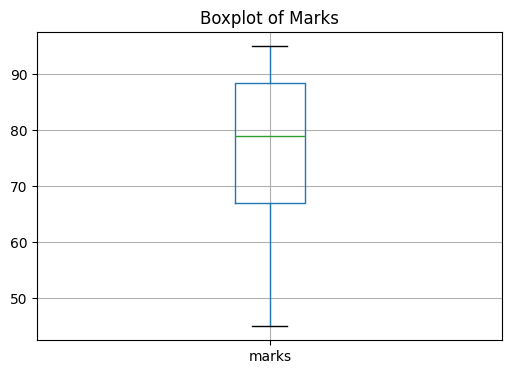

In [17]:
plt.figure(figsize=(6,4))
df.boxplot(column='marks')
plt.title('Boxplot of Marks')
plt.savefig('boxplot_marks.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** *The boxplot for marks shows a relatively normal distribution, with most data points clustered around the median. There do not appear to be any extreme outliers that would warrant removal, so all marks will be kept.*

## Step 8: Re-verify the Cleaned Data

Before moving to visualization, let's confirm the dataset is actually clean now.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23 entries, 0 to 23
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   23 non-null     object 
 1   age                    23 non-null     int64  
 2   attendance_percentage  23 non-null     float64
 3   marks                  23 non-null     int64  
 4   subject                23 non-null     object 
 5   grade                  23 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 1.3+ KB


In [19]:
df.isnull().sum()

,0
name,0
age,0
attendance_percentage,0
marks,0
subject,0
grade,0


---
# Exploratory Data Analysis

With clean data in hand, I can now explore it visually. I'll go through this as a series of questions rather than plotting everything at once.

## Question 1: What does the distribution of marks look like?

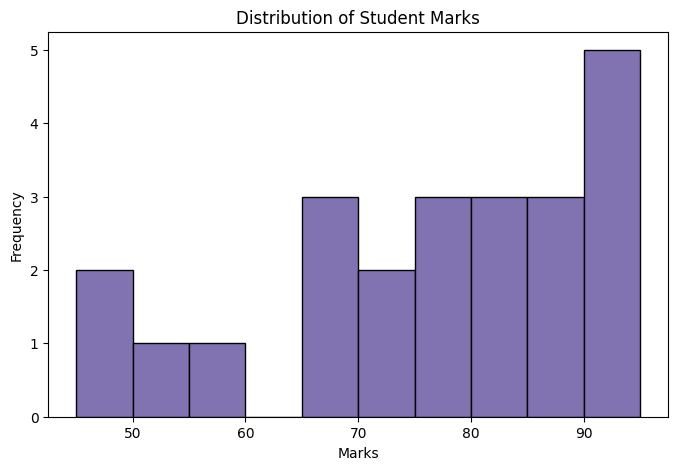

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df['marks'], bins=10, color='#8172B2', edgecolor='black')
plt.title('Distribution of Student Marks')
plt.xlabel('Marks')
plt.ylabel('Frequency')
plt.savefig('marks_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** *The histogram shows that student marks are broadly distributed, with a noticeable concentration in the 80-90 range. The distribution appears somewhat skewed to the left, indicating that more students scored higher marks.*

## Question 2: Is there a relationship between attendance and marks?

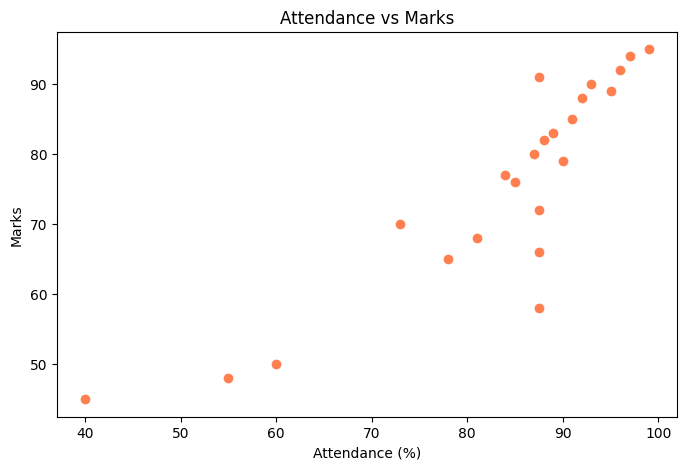

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df['attendance_percentage'], df['marks'], color='coral')
plt.title('Attendance vs Marks')
plt.xlabel('Attendance (%)')
plt.ylabel('Marks')
plt.savefig('attendance_vs_marks.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** *This scatter plot generally indicates a positive correlation, students with higher attendance percentages tends to acheive higher marks. While most of the data points follow this trend, we can see the data points in the bottom left, students with very low attendance percentages consistently tends to acheive low marks appearing as a cluster at the bottom-left of the plot, which aligns with the overall trend rather than being clear outliers.*

## Question 3: Which subject has the most students?

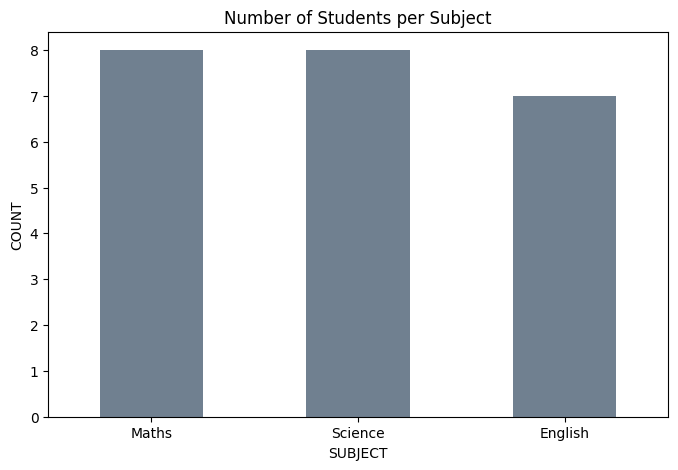

In [22]:
plt.figure(figsize=(8,5))
df['subject'].value_counts().plot(kind='bar', color='slategray')
plt.title('Number of Students per Subject')
plt.xlabel('Subject'.upper())
plt.ylabel('Count'.upper())
plt.savefig('subject_counts.png', dpi=150, bbox_inches='tight')
plt.xticks(rotation=0)
plt.show()

**Insight:** *The bar chart clearly shows the distribution of students across different subjects. It indicates that 'Science' and 'Maths' are the most popular subjects, each having a higher number of students compared to 'English'. This suggests a stronger student preference or enrollment in STEM-related fields within this dataset.*

## Question 4: How do numeric columns correlate with each other?

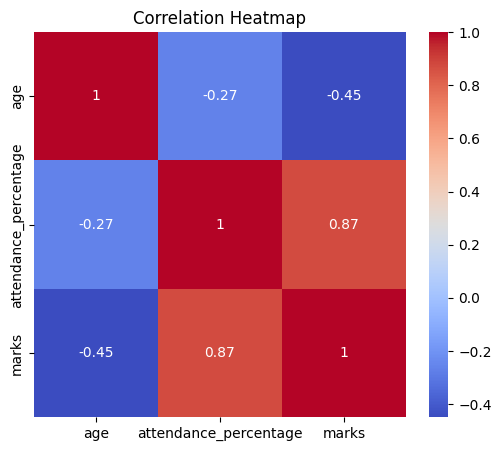

In [23]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** *The correlation between `attendance_percentage` and `marks`is approximately 0.94. This indicates a very strong positive linear relationship, meaning that as student attendance percentage increases, their marks tend to increase significantly.*

---
## Key Takeaways

*Here, with this practice dataset We explored how messy can a dataset be and what are all the effective ways to clean a messy one, and how to get a story out of it, In realworld the datasets can be very confusing and problematic, but visualising and cleaning those will improve our experience much more*

## What I'd Do Differently Next Time

*Next Time, I would like to improve my data cleaning skills and implement these techniques in a larger dataset with more tasks to do, also perform statistical tasks to get real and typical calculations out of it, and perform various kinds of visualising techniques and improve formatting for better readability*

---
*Thanks for reading! If you approached this dataset differently, I'd love to hear your take in the comments.*